# 1: Classifier

In this notebook, we'll train a classifier with `xgboost` to discriminate between points close to the minimum of the likelihood from those far away.

In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import sklearn.metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import json
import supertree
import tl2cgen
import treelite.frontend

_optuna = False

We load the data that we have prepared

In [2]:
df = pd.read_csv('sample_tutorial.csv')
df.describe()

,log_fa,cqL33/fa,cuR/fa,cdR/fa,clL33/fa,ceR/fa,chi2
count,41638.000000,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,41638.000000
mean,6.710931,1.674944e-09,5.206095e-08,7.582442e-08,-1.008463e-07,-1.244107e-08,38.311924
std,0.342768,1.248665e-07,6.214913e-07,6.077427e-07,6.573264e-07,1.339599e-07,29.898190
min,5.995225,-6.841106e-07,-2.875298e-06,-2.889838e-06,-2.939651e-06,-1.981324e-06,12.764648
25%,6.495291,-1.040439e-07,-2.229680e-07,-1.844678e-07,-2.930539e-07,-5.537717e-08,15.528566
50%,6.801755,5.276245e-11,5.222429e-09,9.657293e-08,-5.336264e-08,2.817573e-09,17.654180
75%,6.959833,1.082072e-07,2.491484e-07,2.911214e-07,1.640868e-07,4.984933e-08,80.000000
max,7.518143,9.577512e-07,2.991289e-06,2.873215e-06,2.913317e-06,8.945756e-07,80.000000


We define a cut-off for the points whose likelihood we're going to model, or to discard (try different values)

In [4]:
cutoff = 10.0

X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa']]
y = df['chi2']

sigmoid_width = 0.4
sigmoid = lambda data: 1/(1+np.exp((data-np.min(data)-cutoff)/sigmoid_width))

Text(0, 0.5, '$\\sigma$')

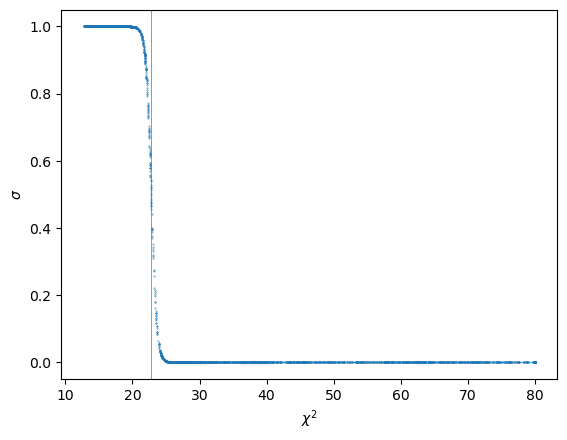

In [5]:
plt.scatter(y, sigmoid(y), s=0.1)

plt.axvline(np.min(y)+cutoff, color='r', lw=0.4)
plt.xlabel(r'$\chi^2$')
plt.ylabel(r'$\sigma$')

An example of how to train a classifier using most of the options:

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

dtrain = xgb.DMatrix(X_train.values, label=sigmoid(y_train))
dval = xgb.DMatrix(X_val.values, label=sigmoid(y_val))

evals = [(dtrain, 'train'), (dval, 'eval')]

## Choosing the right hyperparameters (optional)

In [12]:
def optuna_obj(trial):
    params = {
        'objective': 'reg:squarederror', # Regression with squared error
        'tree_method': 'hist', # Faster tree construction algorithm
        'max_depth': trial.suggest_int('max_depth', 2, 8), # Maximum depth of the tree
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # Step size shrinkage
        'gamma': trial.suggest_float('gamma', 0, 5), # Minimum loss reduction required to make a further partition
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Minimum sum of instance weight needed in a child
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Fraction of samples to use for each tree
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Fraction of features to use for each tree
        'eval_metric': 'mae', # Evaluation metric
        'nthread': -1, # Use all available CPU cores
        'base_score': trial.suggest_float('base_score', -1.0, 1.0), # Initial prediction score
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.2),
    }

    model_clf = xgb.train(params, dtrain, num_boost_round=500, evals=evals, early_stopping_rounds=15, verbose_eval=False)
    predictions = model_clf.predict(dval)
    mae = sklearn.metrics.mean_absolute_error(sigmoid(y_val), predictions)
    return mae

In [13]:
_optuna = True

if _optuna:
  optuna.logging.set_verbosity(optuna.logging.WARNING)
  study = optuna.create_study(direction='minimize')
  study.optimize(optuna_obj, n_trials=400, timeout=120, n_jobs=-1, show_progress_bar=True)

  with open('best_params_clf.json', 'w') as f:
      json.dump(study.best_params, f)


  0%|          | 0/400 [00:00<?, ?it/s]

## Model training

In [14]:
with open('best_params_clf.json', 'r') as f:
    best_params = json.load(f)

best_params

{'max_depth': 6,
 'learning_rate': 0.20528173790125612,
 'gamma': 0.005413466363839631,
 'min_child_weight': 4,
 'subsample': 0.8498414295731881,
 'colsample_bytree': 0.9980262353527711,
 'base_score': -0.551260473382928,
 'reg_alpha': 0.5540501512894949,
 'reg_lambda': 0.37188809736262046}

In [15]:
eval_results = {}

model_clf = xgb.train(best_params | {'objective': 'reg:squarederror', 'tree_method': 'hist', 'eval_metric': ['mae', 'rmse'], 'nthread': -1}, dtrain, num_boost_round=500, evals=evals, early_stopping_rounds=15, verbose_eval=False, evals_result=eval_results)

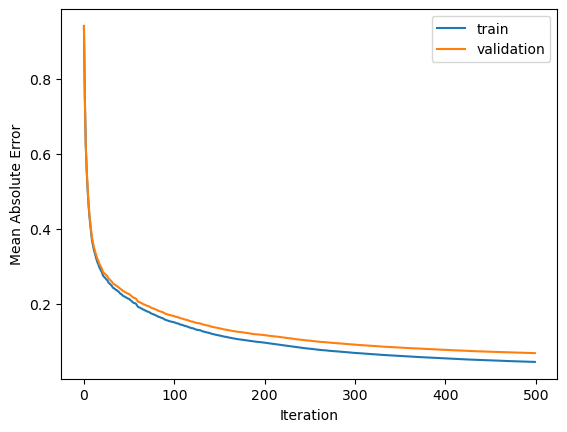

In [16]:
plt.plot(eval_results['train']['mae'], label='train')
plt.plot(eval_results['eval']['mae'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Mean Absolute Error')
plt.legend()

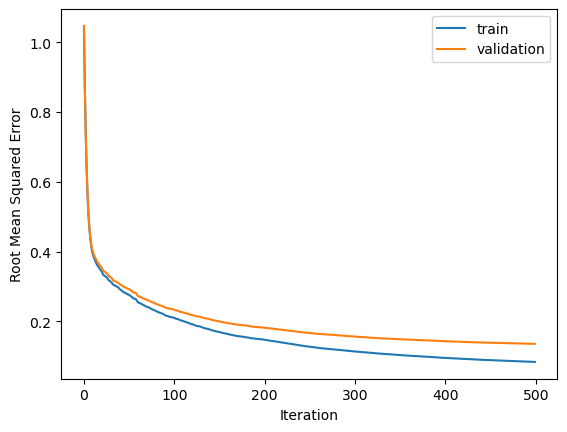

In [17]:
plt.plot(eval_results['train']['rmse'], label='train')
plt.plot(eval_results['eval']['rmse'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Root Mean Squared Error')
plt.legend()

Text(0, 0.5, 'True Positive Rate')

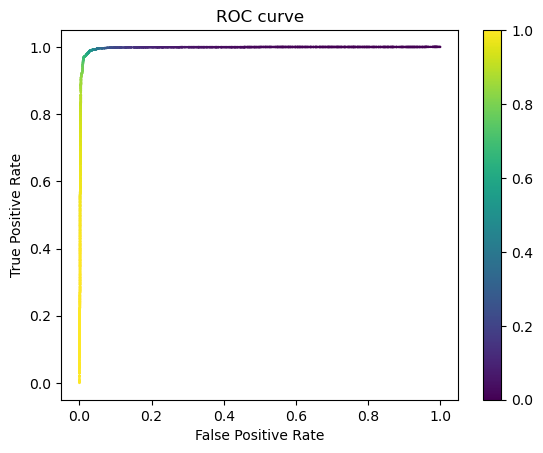

In [20]:
pred_clf = model_clf.predict(dval)

fpr, tpr, thr = sklearn.metrics.roc_curve((y_val.values < np.min(y) + cutoff).astype(int), pred_clf)

plt.scatter(fpr, tpr, c=thr, s=0.5, vmin=0.0, vmax=1.0)
plt.colorbar()
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [22]:
model_clf.save_model('xgb_classifier.ubj')

In [23]:
tree_clf = treelite.frontend.from_xgboost(model_clf)
tl2cgen.export_lib(tree_clf, toolchain='gcc', libpath='xgb_classifier.so', params={'parallel_comp': 4})

[22:54:18] /Users/runner/miniforge3/conda-bld/tl2cgen_1761589514529/work/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


## Tree visulization

In [24]:
st = supertree.SuperTree(model_clf, X_train.values, y_train.values, feature_names = ['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'])

In [25]:
st.show_tree(0)